In [1]:
# import neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append("..")

from src.data_preprocessing import (
    load_data,
    remove_duplicates,
    handle_missing_values,
    correct_dtypes
)

from src.feature_engineering import (
    create_time_features,
    transaction_frequency
)

from src.geolocation import (
    ip_to_int,
    merge_country
)

In [ ]:
# Load Datasets
fraud_df = load_data(
    "../data/raw/Fraud_Data.csv"
)

country_df = load_data(
    "../data/raw/IpAddress_to_Country.csv"
)

print(fraud_df.shape)
print(country_df.shape)

fraud_df.head()
print("Fraud dataset loaded successfully.")

(151112, 11)
Fraud dataset loaded successfully.
(138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [ ]:
# Load Creditcard Datasets
credit_df = load_data(
    "../data/raw/creditcard.csv"
)
print(credit_df.shape)
credit_df.head()
print("Credit dataset loaded successfully.")

(284807, 31)
Credit dataset loaded successfully.


In [ ]:
# Data Cleaning for fraud dataset
fraud_df = remove_duplicates(
    fraud_df
)

fraud_df = handle_missing_values(
    fraud_df
)

fraud_df = correct_dtypes(
    fraud_df
)

fraud_df.info()

Duplicates: 0
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [3]:
# Data Cleaning for creditcard dataset
credit_df = remove_duplicates(
   credit_df
)

credit_df = handle_missing_values(
    credit_df
)

credit_df = correct_dtypes(
    credit_df
)

credit_df.info()

Duplicates: 1081
<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     2

In [4]:
# Save Processed Creditcard Dataset
credit_df.to_csv(
    "../data/processed/creditcard_processed.csv",
    index=False
)

# Display first 5 rows


print("Processed Creditcard dataset saved successfully.")

Processed Creditcard dataset saved successfully.


In [6]:
#Convert IP Address

#If your dataset stores IP addresses as numeric values:

fraud_df["ip_int"] = fraud_df["ip_address"]

In [7]:
fraud_df[
    ["ip_address", "ip_int"]
].head()

,ip_address,ip_int
0,7.327584e+08,7.327584e+08
1,3.503114e+08,3.503114e+08
2,2.621474e+09,2.621474e+09
3,3.840542e+09,3.840542e+09
4,4.155831e+08,4.155831e+08


In [8]:
#Merge Country Information
fraud_country_df = merge_country(
    fraud_df,
    country_df
)

fraud_country_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,1.677886e+07,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,1.684205e+07,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,1.684366e+07,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,1.693873e+07,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,1.697198e+07,16941056.0,16973823.0,Thailand


In [9]:
# Create Time Features
fraud_country_df = create_time_features(
    fraud_country_df
)

fraud_country_df[
    [
        "hour_of_day",
        "day_of_week",
        "time_since_signup"
    ]
].head()

,hour_of_day,day_of_week,time_since_signup
634,3,6,3632215.0
635,20,2,1231637.0
636,23,5,1997534.0
637,16,5,7640897.0
638,4,1,10249579.0


In [10]:
# Transaction Frequency
fraud_country_df = transaction_frequency(
    fraud_country_df
)

fraud_country_df[
    [
        "user_id",
        "transaction_count"
    ]
].head()

,user_id,transaction_count
0,247547,1
1,220737,1
2,390400,1
3,69592,1
4,174987,1


In [11]:
# Fraud Rate by Country
country_fraud = (
    fraud_country_df
    .groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

country_fraud

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Malta                    0.181818
Afghanistan              0.166667
Cote D'ivoire            0.166667
Denmark                  0.159184
Chile                    0.153477
Name: class, dtype: float64

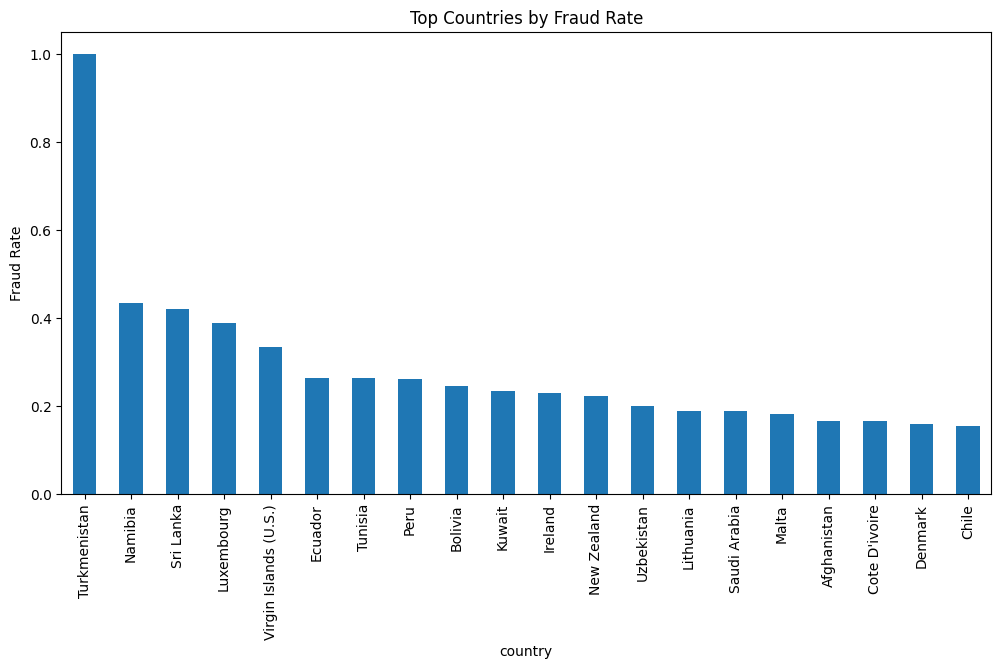

In [12]:
# Visualization
plt.figure(figsize=(12,6))

country_fraud.plot(
    kind="bar"
)

plt.title(
    "Top Countries by Fraud Rate"
)

plt.ylabel(
    "Fraud Rate"
)

plt.show()

In [ ]:
# Save Processed Dataset
fraud_country_df.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

# Display first 5 rows


print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [18]:
fraud_country_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,lower_bound_ip_address,upper_bound_ip_address,country,hour_of_day,day_of_week,time_since_signup,transaction_count
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,1.677886e+07,16778240.0,16779263.0,Australia,3,6,3632215.0,1
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,1.684205e+07,16809984.0,16842751.0,Thailand,20,2,1231637.0,1
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,1.684366e+07,16843264.0,16843775.0,China,23,5,1997534.0,1
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,1.693873e+07,16924672.0,16941055.0,China,16,5,7640897.0,1
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,1.697198e+07,16941056.0,16973823.0,Thailand,4,1,10249579.0,1


In [ ]:
# 2. Target Variable Distribution
fraud_country_df['class'].value_counts()

class
0    116878
1     12268
Name: count, dtype: int64

## 2. Target Variable Distribution

The target variable (`class`) is highly imbalanced:

- Class 0 (Non-Fraud): 116,878 transactions
- Class 1 (Fraud): 12,268 transactions

### Interpretation:
Most transactions are legitimate, which is typical in fraud detection problems. This imbalance must be addressed during model training to avoid bias toward the majority class.


In [24]:
fraud_country_df['transaction_count'] = (
    fraud_country_df.groupby('device_id')['device_id']
    .transform('count')
)

In [26]:
fraud_country_df['transaction_count'].value_counts().sort_index()

transaction_count
1     113812
2       7796
3        195
4         12
5         55
6        144
7        294
8        496
9        585
10       790
11       979
12       948
13       702
14       742
15       525
16       528
17       204
18       144
19        95
20       100
Name: count, dtype: int64

# Markdown Interpretation of Task-1 Output
# Task 1 Output Interpretation

## 1. Dataset Overview
The dataset contains transaction-level information for an e-commerce fraud detection system. Each row represents a single transaction with user behavior, device information, and time-based attributes.



## 3. Feature Engineering Results

### 3.1 Time-Based Features
- `hour_of_day` and `day_of_week` were extracted from transaction timestamps.
- These features help capture behavioral patterns such as unusual transaction timing.

### 3.2 Signup Behavior
- `time_since_signup` measures the time gap between account creation and purchase.
- Short time gaps may indicate suspicious behavior.

### 3.3 Geolocation Feature
- IP addresses were mapped to countries.
- This helps identify inconsistent geographic behavior.

### 3.4 Transaction Count Feature
- Represents how frequently a user/device/IP appears in the dataset.
- Values range from 1 to 20.

#### Interpretation:
- Most entities appear once (normal behavior)
- Some entities appear multiple times, which may indicate suspicious or automated activity

---

## 4. Key Insights

- The dataset is highly imbalanced (fraud is minority class)
- Behavioral features (transaction frequency, time patterns) are important for fraud detection
- IP-based geolocation adds useful context
- Feature engineering significantly improves dataset quality for modeling

---

## 5. Conclusion

Task 1 successfully prepared a clean and feature-rich dataset suitable for machine learning modeling. The next phase will focus on training predictive models to detect fraudulent transactions.